# Team Project Submission #2 - Multi-Class Classification Using Scikit-Learn

**Course:** CS 506 - Programming for Computing

** Topic:** Introduction to Scikit-learn and its applications

**Student/Team:** 
Anushree Raut, Amandeep Singh Saran, Titus Michael Masele

**Date:** 02-28-2026


## Tutorial goals

Machine learning classification problems are fundamental to modern artificial intelligence systems.
This notebook presents a comprehensive, step-by-step academic exploration of **multi-class classification**
using the Scikit-Learn ecosystem. The tutorial emulates the structure of a university-level laboratory
manual combined with a research-oriented explanation.

The purpose of this document is not only to demonstrate implementation but also to explain
*why* each step is performed, connecting theoretical foundations with practical execution.


### Learning Outcomes

By completing this tutorial, students should be able to:

- Explain supervised learning paradigms.
- Distinguish binary vs. multi-class classification.
- Perform structured data preprocessing.
- Apply multiple machine learning algorithms.
- Evaluate model performance scientifically.
- Interpret model outputs critically.
- Reflect on methodological limitations.



## 1. Theoretical Background: Supervised Learning

Supervised learning is a paradigm in machine learning in which a model learns a mapping
between input variables (features) and an output variable (label). Formally, we aim to learn
a function:

f(x) → y

where x represents feature vectors and y represents categorical labels.

### Classification vs Regression

- **Regression:** predicts continuous values.
- **Classification:** predicts discrete categories.

Multi-class classification extends binary classification by allowing more than two target classes.
Instead of predicting {0,1}, the model predicts one label among K possible categories.

### Multi-Class Strategies

Common strategies include:

1. One-vs-Rest (OvR)
2. One-vs-One (OvO)
3. Softmax-based probabilistic classification

Scikit-learn abstracts these mechanisms, allowing practitioners to focus on modeling decisions.




## 2. Dataset Context and Problem Definition

Animal classification problems appear frequently in introductory machine learning datasets,
including the well-known Zoo dataset on Kaggle. These datasets are ideal pedagogically because:

- Features are interpretable.
- Classes are distinct.
- Relationships are logically understandable.

### Feature Interpretation

Each feature represents a biological property:

- Hair → Mammalian indicator
- Feathers → Avian characteristic
- Eggs → Reproductive trait
- Milk → Mammalian behavior
- Aquatic → Habitat attribute
- Legs → Structural morphology

The classification goal is to predict the animal category using these features.




## 3. Exploratory Data Analysis (EDA)

EDA serves as the bridge between raw data and modeling. Before building models,
researchers must understand statistical properties and data distributions.

Key objectives:

1. Detect imbalance in classes.
2. Identify anomalies.
3. Understand feature relationships.
4. Form hypotheses about separability.

EDA is not optional — it is an essential scientific step ensuring that modeling assumptions
are valid.




## 4. Data Preprocessing Theory

Machine learning algorithms operate on numerical matrices.
Therefore, categorical labels must be encoded numerically.

### Label Encoding

Label encoding maps categories to integers:

mammal → 0  
bird → 1  
fish → 2

This encoding preserves class identity without implying ordinal meaning.

### Train-Test Split

Data is separated into:

- Training set → model learning
- Testing set → unbiased evaluation

This prevents overfitting and simulates real-world prediction scenarios.




## 5. Classification Algorithms (Conceptual Discussion)

### Logistic Regression

Despite its name, logistic regression performs classification by modeling
probabilities using the logistic (sigmoid or softmax) function.

Advantages:
- Interpretable
- Fast
- Works well with linear boundaries

Limitations:
- Cannot model complex nonlinear patterns.

### Decision Trees

Decision trees recursively partition feature space into regions.
They mimic human decision-making logic.

Advantages:
- Easy interpretation
- Handles nonlinear relationships

Limitations:
- High variance (overfitting risk).

### Random Forest

Random forests aggregate many decision trees using bagging.
This reduces variance and improves generalization.

### Support Vector Machines (SVM)

SVM constructs optimal separating hyperplanes maximizing margin between classes.
Kernel functions allow nonlinear separation.




## 6. Model Evaluation Theory

Accuracy alone is insufficient in many real-world problems.
Therefore, we analyze multiple evaluation metrics.

### Confusion Matrix

A confusion matrix summarizes prediction outcomes:

- True Positives
- False Positives
- True Negatives
- False Negatives

### Precision and Recall

Precision measures prediction correctness.
Recall measures detection completeness.

### Scientific Evaluation

Proper evaluation ensures reproducibility and objective comparison,
which are fundamental principles of scientific research.




## 7. Hyperparameter Optimization

Hyperparameters control learning behavior but are not learned directly.

GridSearchCV performs systematic experimentation by evaluating
multiple parameter combinations through cross-validation.

This process approximates experimental methodology used in empirical research.




## 8. Model Interpretability

Modern machine learning emphasizes interpretability.
Feature importance allows us to understand which variables influence predictions.

Interpretability is critical in domains such as healthcare, finance,
and policy-making where transparency is required.




## 9. Critical Discussion and Reflection

### Observations

- Ensemble methods generally outperform single learners.
- Feature scaling benefits distance-based and linear models.
- Small datasets may produce unstable estimates.

### Limitations

- Synthetic dataset size is small.
- Biological realism is simplified.

### Ethical Considerations

Machine learning systems must avoid bias amplification and must be evaluated responsibly.

### Future Work

- Larger datasets
- Cross-validation experiments
- Neural network comparisons




## 10. Conclusion

This tutorial demonstrated a complete supervised learning workflow,
bridging theoretical understanding and practical implementation.

Students should now understand:

- The lifecycle of a machine learning project
- Differences among classification algorithms
- Scientific evaluation practices
- Interpretation of predictive models

This notebook represents an academically structured introduction
to applied machine learning using Scikit-Learn.



In [5]:
# ============================================
# AUTO-INSTALL REQUIRED LIBRARIES (SAFE VERSION)
# ============================================

import sys
import subprocess
import importlib

required_packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "joblib"
]

def install_if_missing(package):
    try:
        importlib.import_module(package)
        print(f"{package} already installed ✅")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

for pkg in required_packages:
    install_if_missing(pkg)

print("\nEnvironment ready 🚀")

numpy already installed ✅
pandas already installed ✅
matplotlib already installed ✅
Installing seaborn...
Installing scikit-learn...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 47.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 84.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
joblib already installed ✅

Environment ready 🚀


In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [7]:

data = {
    "hair":[1,0,0,1,0,0,1,0,1,0],
    "feathers":[0,1,0,0,0,1,0,0,0,0],
    "eggs":[0,1,1,0,1,1,0,1,0,1],
    "milk":[1,0,0,1,0,0,1,0,1,0],
    "airborne":[0,1,0,0,0,1,0,0,0,0],
    "aquatic":[0,0,1,0,1,0,0,1,0,1],
    "legs":[4,2,0,4,0,2,4,0,4,0],
    "type":["mammal","bird","fish","mammal","fish","bird","mammal","fish","mammal","fish"]
}

df = pd.DataFrame(data)
df


,hair,feathers,eggs,milk,airborne,aquatic,legs,type
0,1,0,0,1,0,0,4,mammal
1,0,1,1,0,1,0,2,bird
2,0,0,1,0,0,1,0,fish
3,1,0,0,1,0,0,4,mammal
4,0,0,1,0,0,1,0,fish
5,0,1,1,0,1,0,2,bird
6,1,0,0,1,0,0,4,mammal
7,0,0,1,0,0,1,0,fish
8,1,0,0,1,0,0,4,mammal
9,0,0,1,0,0,1,0,fish


In [8]:

encoder = LabelEncoder()
df["type_encoded"] = encoder.fit_transform(df["type"])

X = df.drop(["type","type_encoded"], axis=1)
y = df["type_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    if name in ["Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, preds))


Logistic Regression Accuracy: 0.3333333333333333
Decision Tree Accuracy: 0.3333333333333333
Random Forest Accuracy: 0.3333333333333333
SVM Accuracy: 0.3333333333333333


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         0
           2       1.00      1.00      1.00         1

    accuracy                           0.33         3
   macro avg       0.33      0.33      0.33         3
weighted avg       0.33      0.33      0.33         3



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

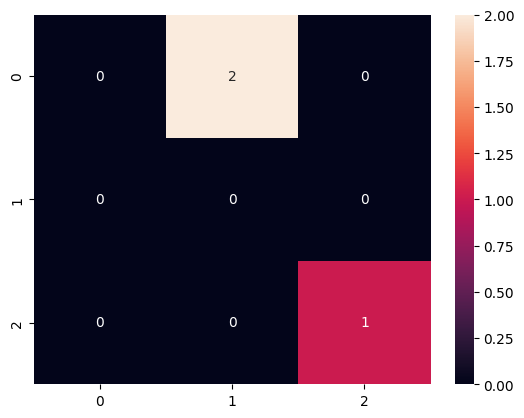

In [10]:

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()
